In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)

In [15]:
X, y = load_breast_cancer(as_frame=True, return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=500))
])

model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]

pred = (proba >= 0.5).astype(int)

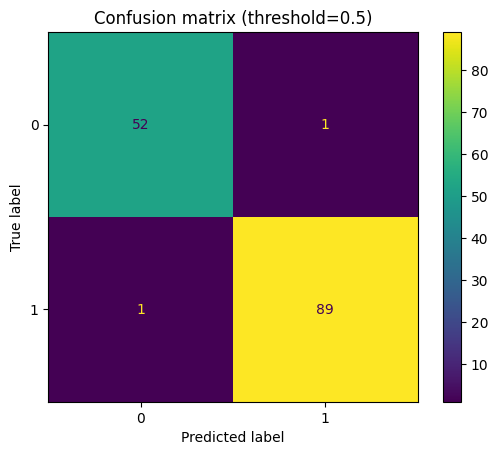

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



In [16]:
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion matrix (threshold=0.5)")
plt.show()

print(classification_report(y_test, pred))

In [17]:
thresholds = np.linspace(0.05, 0.95, 19)

rows = []

for t in thresholds:
    pred_t = (proba >= t).astype(int)
    prec = precision_score(y_test, pred_t)
    rec = recall_score(y_test, pred_t)
    rows.append((t, prec, rec))

thr_table = pd.DataFrame(rows, columns=["threshold", "precision", "recall"])
thr_table

,threshold,precision,recall
0,0.05,0.909091,1.000000
1,0.10,0.927835,1.000000
2,0.15,0.927835,1.000000
3,0.20,0.957447,1.000000
4,0.25,0.967742,1.000000
5,0.30,0.967742,1.000000
6,0.35,0.967742,1.000000
7,0.40,0.988889,0.988889
8,0.45,0.988889,0.988889
9,0.50,0.988889,0.988889


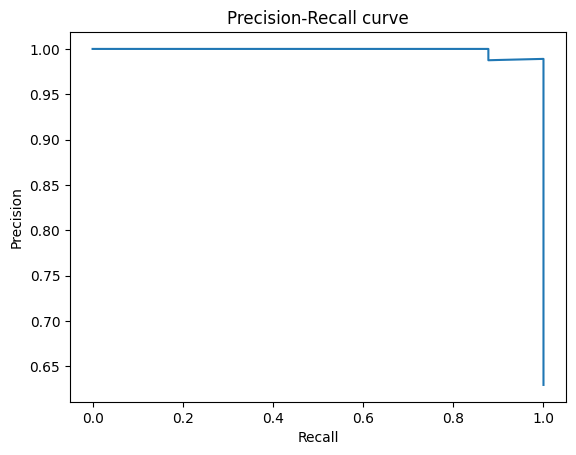

Average precision 0.999


In [18]:
prec, rec, thr = precision_recall_curve(y_test, proba)

plt.figure()
plt.plot(rec, prec)
plt.title("Precision-Recall curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

ap = average_precision_score(y_test, proba)
print("Average precision", round(ap, 3))

In [19]:
analysis_df = X_test.copy()
analysis_df["y_true"] = y_test.values
analysis_df["proba_pos"] = proba
analysis_df["pred"] = pred
analysis_df["correct"] = (analysis_df["y_true"] == analysis_df["pred"])


analysis_df["confidence"] = np.maximum(analysis_df["proba_pos"], 1 - analysis_df["proba_pos"])

worst_mistakes = (
    analysis_df[analysis_df["correct"] == False]
    .sort_values("confidence", ascending=False)
    .head(10)
)

worst_mistakes[["y_true", "pred", "proba_pos", "confidence"]]

,y_true,pred,proba_pos,confidence
73,0,1,0.892931,0.892931
541,1,0,0.383064,0.616936
